# Notebook 6: RNNs
In this notebook we will train a RNN to recognise nationalities based on surnames

### Downloading data
First, let's dowload the surname database, which contains surnames form 18 nationalities

In [1]:
# Download and extract the data
!wget https://download.pytorch.org/tutorial/data.zip
!unzip data.zip -d names_data



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://download.pytorch.org/t]87Saving 'data.zip'
87data.zip              27% [=======>                      ]  775.09K    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87data.zip             100% [=============================>]    2.74M   12.60MB/s87HTTP response 200  [https://download.pytorch.org/tutorial/data.zip]
87data.zip             100% [=============================>]    2.74M   12.60MB/s87[Files: 1  Bytes: 2.74M [2.37MB]8Archive:  data.zip
   creating: names_data/data/
  inflating: names_data/data/eng-fra.txt  
   creating: names_data/data/names/
  inflating: names_data/data/names/Arabic.txt  
  inflating: names_data/data/names/Chinese.txt  
  inflating: names_data/data/names/Czech.txt  
  inflating: names_data/data/names/Dutch.txt  
  inflating: names_data/data/names/English.txt  
  inflating: names_data/data/names/French.txt  
  inflating: names_data/data/names/German.txt  
  inflating: names_data/data/names/Greek.txt  


### Preparing the data
First, let's convert the unicode strinfs to ASCII (with some help from stack overflow), and define our labels (categories here), i.e. the languages

In [20]:
# Preparing the data
from io import open
import glob
import os

def findFiles(path): return glob.glob(path)

print(findFiles('names_data/data/names/*.txt'))

import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

for filename in findFiles('names_data/data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

['names_data/data/names/Arabic.txt', 'names_data/data/names/Chinese.txt', 'names_data/data/names/Czech.txt', 'names_data/data/names/Dutch.txt', 'names_data/data/names/English.txt', 'names_data/data/names/French.txt', 'names_data/data/names/German.txt', 'names_data/data/names/Greek.txt', 'names_data/data/names/Irish.txt', 'names_data/data/names/Italian.txt', 'names_data/data/names/Japanese.txt', 'names_data/data/names/Korean.txt', 'names_data/data/names/Polish.txt', 'names_data/data/names/Portuguese.txt', 'names_data/data/names/Russian.txt', 'names_data/data/names/Scottish.txt', 'names_data/data/names/Spanish.txt', 'names_data/data/names/Vietnamese.txt']
Slusarski


In [21]:
print(category_lines['Italian'][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


We want the input in the form of pytorch thensors, so let's build a mapping of letters to integers
e.g. a=[1, 0, 0, 0, 0, ...]

In [22]:
# Turning names into tensors
import torch

# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a world into a <world_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def worldToTensor(world):
    tensor = torch.zeros(len(world), 1, n_letters)
    for li, letter in enumerate(world):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

print(letterToTensor('J'))

print(worldToTensor('Jones').size())

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([5, 1, 57])


### Creating the network
Now, let's defeine our RNN. We have:
* input -> hidden layer
* hidden -> output layer
* softmax applied to the output


Since RNNs are **recurrent**, the forward pass takes as an argument also `hidden`, which is concatenated to the inut to form a new input

In [23]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        hidden = self.i2h(combined)
        output = self.h2o(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):   # for the first iteration we need to concat the input with something: zeros
        return torch.zeros(1, self.hidden_size)

n_hidden = 32
rnn = RNN(n_letters, n_hidden, n_categories)

In [24]:
# Quick checks before training: how does it work?
input = letterToTensor('A')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input, hidden)

In [25]:
input = lineToTensor('Albert')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input[0], hidden)
print(output)

tensor([[-2.9070, -2.9931, -2.8437, -2.9852, -2.7874, -2.7257, -2.9184, -2.9540,
         -2.8501, -2.8480, -2.7345, -2.7613, -2.9262, -3.0986, -2.9538, -2.9316,
         -3.0357, -2.8627]], grad_fn=<LogSoftmaxBackward0>)


It would be cool to see directly the most likely category, let's define a function to do it

In [26]:
# Preparing for training
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

print(categoryFromOutput(output))

('French', 5)


In [27]:
# Looking at some of our training examples
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('category =', category, '/ line =', line)

category = Irish / line = Ruadhan
category = Portuguese / line = Santana
category = French / line = Glaisyer
category = Chinese / line = Cui
category = Spanish / line = Franco
category = Dutch / line = Rossem
category = Spanish / line = Robles
category = Arabic / line = Harb
category = Scottish / line = Fleming
category = Chinese / line = Ping


### Training loop
As usual, we define our training loop. For the loss function, we will use **negative log likelihood**

In [34]:
criterion = nn.NLLLoss()
learning_rate = 0.009
optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)

def train(category_tensor, line_tensor):
    hidden = rnn.initHidden()

    rnn.zero_grad()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    return output, loss.item()

### Let's train!!

In [35]:
import time
import math

n_iters = 130000
print_every = 5000
plot_every = 1000

# Keep track of losses for plotting
current_loss = 0

# It could take a while... let's add something for us to look at the status
def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss

    # Print ``iter`` number, loss, name and guess
    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    # Add current loss avg to list of losses
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

5000 3% (0m 1s) 1.9786 Freitas / Greek ✗ (Portuguese)
10000 7% (0m 3s) 0.2158 Barros / Portuguese ✓
15000 11% (0m 5s) 1.9200 Silva / Czech ✗ (Portuguese)
20000 15% (0m 7s) 1.0839 Segher / German ✗ (Dutch)
25000 19% (0m 8s) 2.2267 Marmo / Portuguese ✗ (Italian)
30000 23% (0m 10s) 1.2238 Sabbagh / Arabic ✓
35000 26% (0m 12s) 0.1569 Guan / Chinese ✓
40000 30% (0m 14s) 0.4161 Mui / Chinese ✓
45000 34% (0m 16s) 0.2230 Kozumplikova / Czech ✓
50000 38% (0m 17s) 1.5711 Sienkiewicz / German ✗ (Polish)
55000 42% (0m 19s) 0.8009 Mcgregor / Scottish ✓
60000 46% (0m 21s) 1.8950 Ridge / Irish ✗ (English)
65000 50% (0m 23s) 0.0582 Quach / Vietnamese ✓
70000 53% (0m 25s) 1.6534 Rios / Greek ✗ (Portuguese)
75000 57% (0m 26s) 0.4800 Ciardha / Irish ✓
80000 61% (0m 28s) 1.5362 Faucher / French ✓
85000 65% (0m 30s) 0.6729 Dang / Vietnamese ✓
90000 69% (0m 32s) 0.9862 Zapatero / Italian ✗ (Spanish)
95000 73% (0m 34s) 5.0771 Komo / Japanese ✗ (Czech)
100000 76% (0m 37s) 1.7774 Dael / Spanish ✗ (Dutch)
10500

### Looking into our training
First, let's **plot the loss function**. We want to make sure it was flat when we stopped the training
A good way to visualize results of a multi-class classification problem is to build a **confusion matrix** of the results

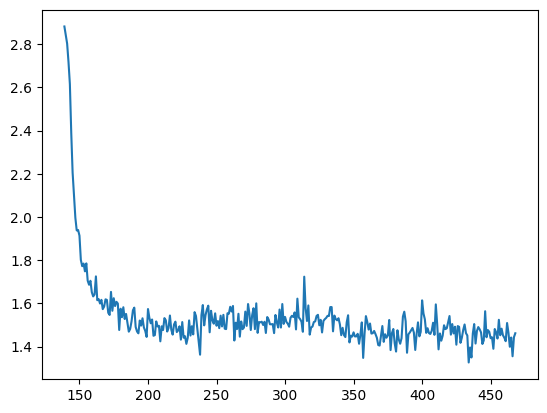

In [36]:
# Plotting the results
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)

/tmp/ipykernel_9229/3585656379.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipykernel_9229/3585656379.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


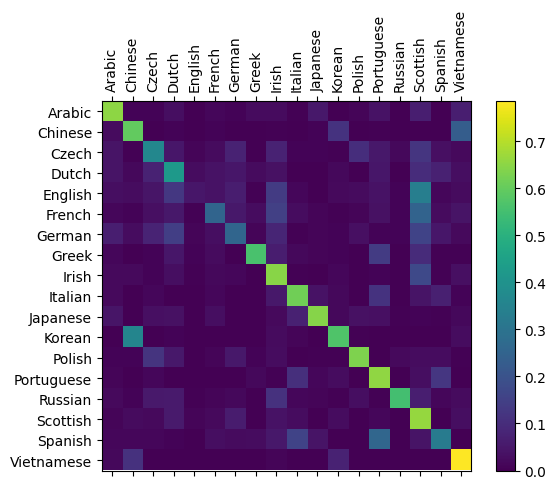

In [37]:
# Keep track of correct guesses in a confusion matrix
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000

# Just return an output given a line
def evaluate(line_tensor):
    hidden = rnn.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    return output

# Go through a bunch of examples and record which are correctly guessed
for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1

# Normalize by dividing every row by its sum
for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

# Set up plot
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

# Set up axes
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

# Force label at every tick
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# sphinx_gallery_thumbnail_number = 2
plt.show()

Lastly, let's play with some names and see if the trained network can get them

In [48]:
def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line)
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line))

        # Get top N categories
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []

        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

predict('Wu')
predict('Noether')
predict('Goeppert-Mayer')
predict('Fazzino')


> Wu
(-0.23) Korean
(-2.24) Chinese
(-2.87) Vietnamese

> Noether
(-1.45) German
(-1.71) Dutch
(-2.04) Scottish

> Goeppert-Mayer
(-0.33) Irish
(-1.90) Korean
(-2.83) Scottish

> Fazzino
(-0.15) Italian
(-3.16) Japanese
(-3.46) Spanish
